In [1]:
!git clone https://github.com/bowang-lab/MedSAM

fatal: destination path 'MedSAM' already exists and is not an empty directory.


In [2]:
%cd MedSAM

/kaggle/working/MedSAM


In [3]:
# %% environment and functions
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F

# visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :] # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=None,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed, # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
        multimask_output=False,
        )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg


In [4]:
# MedSAM_CKPT_PATH = "/kaggle/input/models/jimsukanand/medsam/pytorch/default/1/medsam_vit_b.pth"
MedSAM_CKPT_PATH = "/kaggle/input/models/jimmyanand/tumorsam1002/pytorch/default/1/TumorSAM.pth"
device = "cuda:0"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
# medsam_model.load_state_dict(torch.load('/kaggle/input/models/jimsukanand/tumorsam/pytorch/default/1/TumorSAM.pth'))
medsam_model = medsam_model.to(device)
medsam_model.eval()

# img_np = io.imread('/content/MedSAM/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Glioma/enh_1845.png')
# if len(img_np.shape) == 2:
#     img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
# else:
#     img_3c = img_np
# H, W, _ = img_3c.shape

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


In [5]:
!pip install tqdm

In [6]:
from tqdm import tqdm

In [7]:
!pip install opendatasets

In [8]:
import opendatasets as od

In [9]:
od.download("https://www.kaggle.com/datasets/briscdataset/brisc2025")

Skipping, found downloaded files in "./brisc2025" (use force=True to force download)


In [10]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from skimage import transform


class TumorDataset(Dataset):
    def __init__(self, root_dir, split="train", image_size=1024):
        """
        root_dir:
            brisc2025/

        split:
            train or test
        """

        self.root_dir = root_dir
        self.split = split
        self.image_size = image_size
        self.samples = []

        image_dir = os.path.join(root_dir, split, "images")
        mask_dir  = os.path.join(root_dir, split, "masks")

        # Collect all jpg images
        for file in os.listdir(image_dir):
            if file.endswith(".jpg") or file.endswith(".jpeg") or file.endswith(".png"):

                img_path = os.path.join(image_dir, file)

                # change .jpg -> .png for mask
                mask_name = os.path.splitext(file)[0] + ".png"
                mask_path = os.path.join(mask_dir, mask_name)

                if os.path.exists(mask_path):
                    self.samples.append((img_path, mask_path))

        print(f"Total {split} samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, mask_path = self.samples[idx]

        # ---------------- IMAGE ----------------
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        # convert grayscale -> 3 channel
        image = np.stack([image, image, image], axis=-1)

        # ---------------- MASK ----------------
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            raise ValueError(f"Mask not found: {mask_path}")

        # ---------------- RESIZE ----------------
        image = transform.resize(
            image,
            (self.image_size, self.image_size, 3),
            order=3,
            preserve_range=True,
            anti_aliasing=True
        ).astype(np.float32)

        mask = transform.resize(
            mask,
            (self.image_size, self.image_size),
            order=0,
            preserve_range=True,
            anti_aliasing=False
        ).astype(np.float32)

        # ---------------- NORMALIZE ----------------
        image = (image - image.min()) / np.clip(
            image.max() - image.min(),
            a_min=1e-8,
            a_max=None
        )

        # ---------------- BINARY MASK ----------------
        if mask.max() > 1:
            mask = mask / 255.0

        mask = (mask > 0.5).astype(np.float32)

        # ---------------- TO TENSOR ----------------
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

In [11]:
from torch.utils.data import DataLoader

train_dataset = TumorDataset(
    root_dir="/kaggle/working/MedSAM/brisc2025/brisc2025/segmentation_task",
    split = "train",
    image_size=1024
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    num_workers=4,
    pin_memory=True
)

test_dataset = TumorDataset(
    root_dir="/kaggle/working/MedSAM/brisc2025/brisc2025/segmentation_task",
    split = "test",
    image_size=1024
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    num_workers=4,
    pin_memory=True
)

Total train samples: 3933
Total test samples: 860


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(dataset, num_samples=2):
    plt.figure(figsize=(10, 5 * num_samples))

    for i in range(num_samples):
        image, mask = dataset[i]

        # Convert tensor → numpy
        image = image.permute(1, 2, 0).numpy()  # (H, W, 3)
        mask = mask.squeeze(0).numpy()          # (H, W)

        # Undo normalization (important for display)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image * std) + mean
        image = np.clip(image, 0, 1)

        # Plot Image
        plt.subplot(num_samples, 2, i * 2 + 1)
        plt.imshow(image)
        plt.title(f"Image {i}")
        plt.axis("off")

        # Plot Mask
        plt.subplot(num_samples, 2, i * 2 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Mask {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

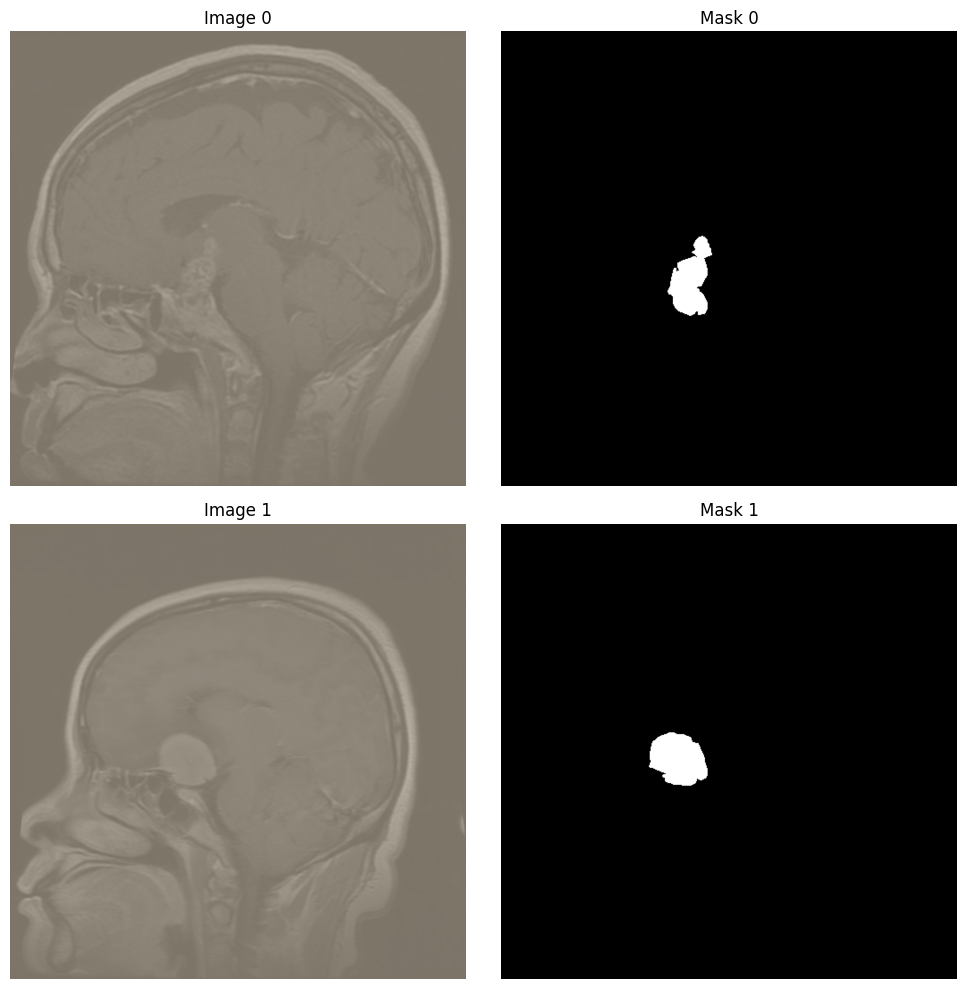

In [13]:
visualize_samples(train_dataset, num_samples=2)

In [14]:
import torch.nn.functional as F

def dice_loss(pred, target, smooth=1e-5):
    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))

    loss = 1 - (2 * intersection + smooth) / (union + smooth)
    return loss.mean()


def bce_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target)

In [15]:
import torch.nn.functional as F

In [16]:
import torch
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, device):

      model.train()

      total_loss = 0

      scaler = torch.cuda.amp.GradScaler()

      for input_image, masks in tqdm(train_loader):
        input_image = input_image.to(device)
        masks = masks.to(device)
        with torch.no_grad():
          image_embedding = medsam_model.image_encoder(input_image)

          sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
              points = None,
              boxes =  None,
              masks =  None,
          )
        low_res_masks, iou_predictions = medsam_model.mask_decoder(
          image_embeddings=image_embedding,
          image_pe=medsam_model.prompt_encoder.get_dense_pe(),
          sparse_prompt_embeddings=sparse_embeddings,
          dense_prompt_embeddings=dense_embeddings,
          multimask_output=False,
        )

        upscaled_masks = F.interpolate(
    low_res_masks,
    size=(1024, 1024),
    mode="bilinear",   # or "nearest"
    align_corners=False
        )

        loss_mask = bce_loss(upscaled_masks, masks) + dice_loss(upscaled_masks, masks)


        loss = loss_mask

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

      return total_loss / len(dataloader)

In [17]:
# Set up the optimizer, hyperparameter tuning will improve performance here
lr = 1e-4
wd = 1e-4
optimizer = torch.optim.Adam(medsam_model.mask_decoder.parameters(), lr=lr, weight_decay=wd)

loss_fn = torch.nn.MSELoss()
# loss_fn = torch.nn.BCELoss()

In [18]:
for i in range(30):
    train_one_epoch(medsam_model, train_loader, optimizer, device)

/tmp/ipykernel_261/2095500706.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  4%|▍         | 41/984 [02:57<1:08:02,  4.33s/it]


KeyboardInterrupt: 

In [20]:
torch.save(medsam_model.state_dict(), 'TumorSAM_Final.pth')

In [ ]:
!split -b 50M /kaggle/working/MedSAM/TumorSAM.pth TumorSAM_part_

In [125]:
img_np = io.imread('/kaggle/working/MedSAM/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00020_gl_ax_t1.jpg')
if len(img_np.shape) == 2:
    img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
else:
    img_3c = img_np
H, W, _ = img_3c.shape

In [126]:
alpha = [0.4074, 0.4567, 0.1767, 0.1620]

In [127]:
x_center = alpha[0] * W
y_center = alpha[1] * H
width    = alpha[2] * W
height   = alpha[3] * H

x1 = int(x_center - width/2)
y1 = int(y_center - height/2)
x2 = int(x_center + width/2)
y2 = int(y_center + height/2)

In [128]:
#%% image preprocessing and model inference
img_1024 = transform.resize(img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
img_1024 = (img_1024 - img_1024.min()) / np.clip(
    img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None
)  # normalize to [0, 1], (H, W, 3)
# convert the shape to (3, H, W)
img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)

box_np = np.array([[x1, y1, x2, y2]])
# transfer box_np t0 1024x1024 scale
box_1024 = box_np / np.array([W, H, W, H]) * 1024
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_1024_tensor) # (1, 256, 64, 64)

medsam_seg = medsam_inference(medsam_model, image_embedding, box_1024, H, W)

In [ ]:
#%% visualize results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_3c)
show_box(box_np[0], ax[0])
ax[0].set_title("Input Image and Bounding Box")
ax[1].imshow(img_3c)
show_mask(medsam_seg, ax[1])
show_box(box_np[0], ax[1])
ax[1].set_title("MedSAM Segmentation")
plt.show()